In [1]:
set.seed(405)
options(stringsAsFactors = FALSE)

In [2]:
required_packages <- c("dplyr", "ggplot2", "readr", "tibble", "tidyr", "forcats")
missing_packages <- required_packages[!vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)]
if (length(missing_packages) > 0) install.packages(missing_packages, repos = "https://cloud.r-project.org")
invisible(lapply(required_packages, library, character.only = TRUE))

Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘tibble’ was built under R version 4.4.3”


In [3]:
model_tbl <- readr::read_csv("../output/derived/gss_2024_model_table.csv", show_col_types = FALSE)
model_tbl <- model_tbl %>%
  dplyr::mutate(
    confinan_ord = as.integer(confinan_ord),
    polviews_bin = factor(polviews_bin, levels = c("Liberal", "Moderate", "Conservative")),
    degree = as.factor(degree),
    sex = as.factor(sex),
    region = as.factor(region)
  )

In [4]:
sample_overview <- tibble::tibble(
  metric = c("n_rows", "n_cols", "age_mean", "age_sd", "income_mean", "income_sd"),
  value = c(
    nrow(model_tbl),
    ncol(model_tbl),
    mean(model_tbl$age, na.rm = TRUE),
    sd(model_tbl$age, na.rm = TRUE),
    mean(model_tbl$income, na.rm = TRUE),
    sd(model_tbl$income, na.rm = TRUE)
  )
)
sample_overview

metric,value
<chr>,<dbl>
n_rows,2232.000000
n_cols,11.000000
age_mean,49.284050
age_sd,17.269217
income_mean,11.055108
income_sd,2.464469


In [5]:
outcome_dist <- model_tbl %>%
  dplyr::count(confinan_ord, name = "n") %>%
  dplyr::mutate(prop = n / sum(n))
outcome_dist

confinan_ord,n,prop
<int>,<int>,<dbl>
1,379,0.1698029
2,1274,0.5707885
3,579,0.2594086


In [6]:
outcome_by_ideo <- model_tbl %>%
  dplyr::count(polviews_bin, confinan_ord, name = "n") %>%
  dplyr::group_by(polviews_bin) %>%
  dplyr::mutate(prop_within_ideo = n / sum(n)) %>%
  dplyr::ungroup()
outcome_by_ideo

polviews_bin,confinan_ord,n,prop_within_ideo
<fct>,<int>,<int>,<dbl>
Liberal,1,114,0.1583333
Liberal,2,407,0.5652778
Liberal,3,199,0.2763889
Moderate,1,150,0.1838235
Moderate,2,459,0.5625000
Moderate,3,207,0.2536765
Conservative,1,115,0.1652299
Conservative,2,408,0.5862069
Conservative,3,173,0.2485632


In [7]:
age_income_by_outcome <- model_tbl %>%
  dplyr::group_by(confinan_ord) %>%
  dplyr::summarise(
    n = dplyr::n(),
    age_mean = mean(age, na.rm = TRUE),
    age_sd = sd(age, na.rm = TRUE),
    income_mean = mean(income, na.rm = TRUE),
    income_sd = sd(income, na.rm = TRUE),
    .groups = "drop"
  )
age_income_by_outcome

confinan_ord,n,age_mean,age_sd,income_mean,income_sd
<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,379,52.16887,18.27257,10.96834,2.524808
2,1274,50.23862,17.50007,11.11774,2.378606
3,579,45.29534,15.32500,10.97409,2.606424


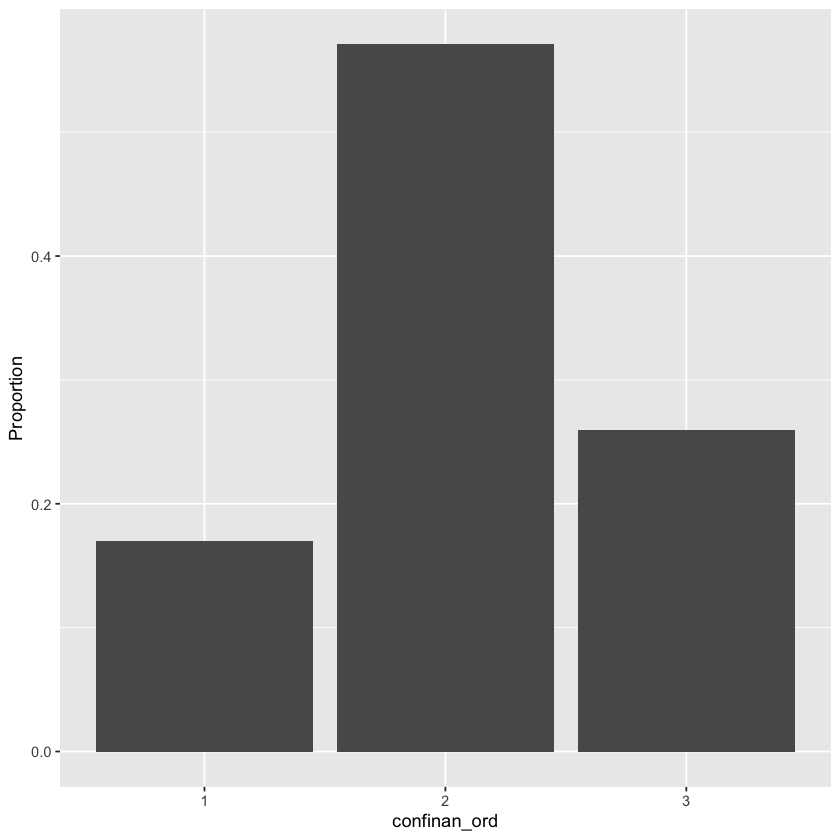

In [8]:
p_outcome <- ggplot2::ggplot(outcome_dist, ggplot2::aes(x = factor(confinan_ord), y = prop)) +
  ggplot2::geom_col() +
  ggplot2::labs(x = "confinan_ord", y = "Proportion")
p_outcome

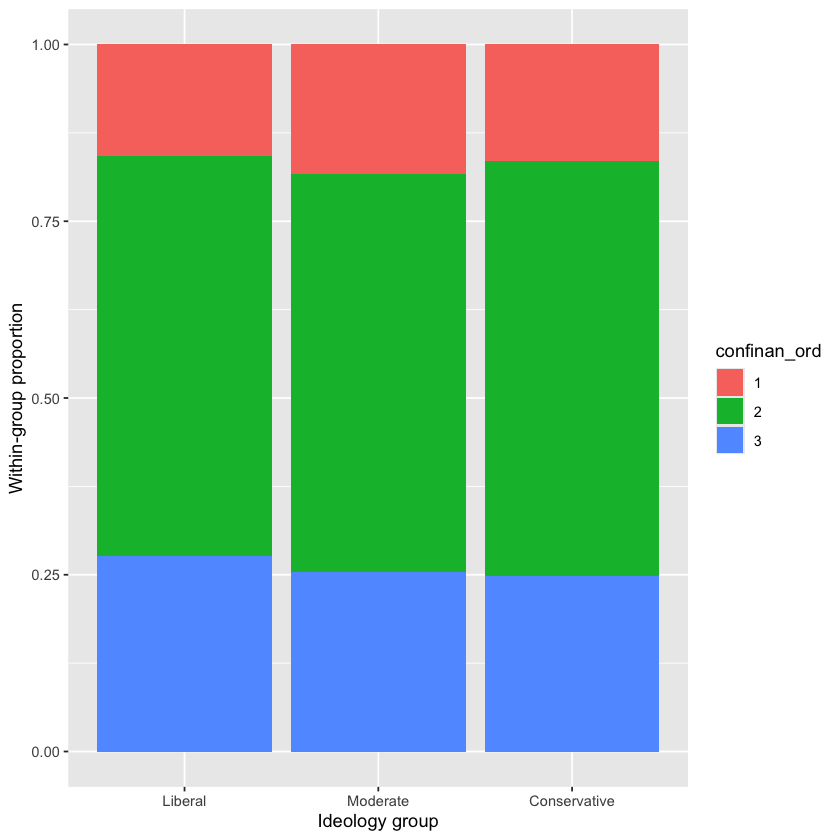

In [9]:
p_ideo <- ggplot2::ggplot(outcome_by_ideo, ggplot2::aes(x = polviews_bin, y = prop_within_ideo, fill = factor(confinan_ord))) +
  ggplot2::geom_col(position = "stack") +
  ggplot2::labs(x = "Ideology group", y = "Within-group proportion", fill = "confinan_ord")
p_ideo

In [10]:
prior_plan <- tibble::tribble(
  ~parameter_block, ~baseline_prior, ~sensitivity_prior_1, ~sensitivity_prior_2, ~rationale,
  "cutpoints", "normal(0, 2.5)", "normal(0, 1.5)", "normal(0, 5)", "Outcome has 3 levels; moderate scale on latent logit axis",
  "beta_std_predictors", "normal(0, 1)", "normal(0, 0.5)", "normal(0, 2)", "age_std and income_std are standardized",
  "beta_categorical", "normal(0, 1)", "normal(0, 0.5)", "normal(0, 2)", "Regularize dummy coefficients to avoid overfit",
  "hier_alpha_mu", "normal(0, 1)", "normal(0, 0.5)", "normal(0, 2)", "Centered ideology-level baseline on logit scale",
  "hier_alpha_sigma", "normal+(0, 1)", "normal+(0, 0.5)", "normal+(0, 2)", "Controls between-ideology dispersion"
)
prior_plan

parameter_block,baseline_prior,sensitivity_prior_1,sensitivity_prior_2,rationale
<chr>,<chr>,<chr>,<chr>,<chr>
cutpoints,"normal(0, 2.5)","normal(0, 1.5)","normal(0, 5)",Outcome has 3 levels; moderate scale on latent logit axis
beta_std_predictors,"normal(0, 1)","normal(0, 0.5)","normal(0, 2)",age_std and income_std are standardized
beta_categorical,"normal(0, 1)","normal(0, 0.5)","normal(0, 2)",Regularize dummy coefficients to avoid overfit
hier_alpha_mu,"normal(0, 1)","normal(0, 0.5)","normal(0, 2)",Centered ideology-level baseline on logit scale
hier_alpha_sigma,"normal+(0, 1)","normal+(0, 0.5)","normal+(0, 2)",Controls between-ideology dispersion


In [11]:
dir.create("../output/eda", recursive = TRUE, showWarnings = FALSE)
dir.create("../output/prior", recursive = TRUE, showWarnings = FALSE)
readr::write_csv(sample_overview, "../output/eda/sample_overview.csv")
readr::write_csv(outcome_dist, "../output/eda/outcome_distribution.csv")
readr::write_csv(outcome_by_ideo, "../output/eda/outcome_by_ideology.csv")
readr::write_csv(age_income_by_outcome, "../output/eda/age_income_by_outcome.csv")
readr::write_csv(prior_plan, "../output/prior/prior_plan.csv")
ggplot2::ggsave(filename = "../output/eda/outcome_distribution.png", plot = p_outcome, width = 7, height = 4, dpi = 150)
ggplot2::ggsave(filename = "../output/eda/outcome_by_ideology.png", plot = p_ideo, width = 8, height = 4.5, dpi = 150)